<a href="https://colab.research.google.com/github/jaeheechillin3/pytorch_projects/blob/main/vid1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
# basic tensors, data types
z1 = torch.zeros(5, 3)
print(z1)
print(z1.dtype)

z2 = torch.zeros((5,3), dtype = torch.int16)
print(z2)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
torch.float32
tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int16)


In [5]:
# setting seeds for reproducable results
torch.manual_seed(1000)
r1 = torch.rand(3,3)
print(r1)

r2 = torch.rand(3,3)
print(r2)

torch.manual_seed(1000)
r3 = torch.rand(3,3)
print(r3) # equal to r1

tensor([[0.3189, 0.6136, 0.4418],
        [0.2580, 0.2724, 0.6261],
        [0.4410, 0.3653, 0.3535]])
tensor([[0.5971, 0.3572, 0.4807],
        [0.4217, 0.1254, 0.6818],
        [0.0571, 0.6818, 0.0473]])
tensor([[0.3189, 0.6136, 0.4418],
        [0.2580, 0.2724, 0.6261],
        [0.4410, 0.3653, 0.3535]])


In [7]:
# elementary operations
ones = torch.ones(3, 2)
print(ones)

twos = torch.ones(3,2) * 2
print(twos)

threes = ones + twos  # size must match
print(threes)

# more operations
r = torch.rand(2,2) - 0.5 * 2
print(r)
print(torch.abs(r))
print(torch.asin(r))
print(torch.det(r))
print(torch.svd(r))
print(torch.std_mean(r))
print(torch.max(r))

tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[2., 2.],
        [2., 2.],
        [2., 2.]])
tensor([[3., 3.],
        [3., 3.],
        [3., 3.]])
tensor([[-0.4029, -0.6428],
        [-0.5193, -0.5783]])
tensor([[0.4029, 0.6428],
        [0.5193, 0.5783]])
tensor([[-0.4146, -0.6982],
        [-0.5460, -0.6167]])
tensor(-0.1008)
torch.return_types.svd(
U=tensor([[-0.6983, -0.7158],
        [-0.7158,  0.6983]]),
S=tensor([1.0821, 0.0932]),
V=tensor([[ 0.6035, -0.7974],
        [ 0.7974,  0.6035]]))
(tensor(0.1020), tensor(-0.5358))
tensor(-0.4029)


In [15]:
# image classifier!
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    self.conv1 = nn.Conv2d(1, 6, 3)
    self.conv2 = nn.Conv2d(6, 16, 3)

    self.fc1 = nn.Linear(16 * 6 * 6, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = F.max_pool2d(F.relu(self.conv1(x)), (2,2))
    x = F.max_pool2d(F.relu(self.conv2(x)), 2)
    x = x.view(-1, self.num_flat_features(x))
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

  def num_flat_features(self, x):
    size = x.size()[1:]   # all dimensions except the batch dimension
    num_features = 1
    for s in size:
      num_features *= s
    return num_features

In [16]:
net = LeNet()
print(net)

input = torch.rand(1, 1, 32, 32)
print('\nImage batch shape:')
print(input.shape)

output = net(input)
print('\nRaw output:')
print(output)
print(output.shape)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Image batch shape:
torch.Size([1, 1, 32, 32])

Raw output:
tensor([[ 0.0077,  0.0342,  0.0431,  0.0483,  0.1605,  0.0191, -0.0089, -0.0833,
          0.0398,  0.0690]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


In [19]:
%matplotlib inline
import torchvision
import torchvision.transforms as transforms

In [21]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [01:28<00:00, 1.94MB/s]


In [22]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

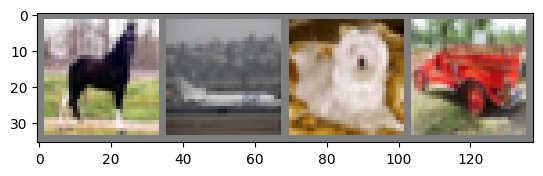

In [24]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
  img = img / 2 + 0.5   # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))